In [1]:
# Active Learning with Equity Constraints
# Goal: Simulate annotation budget scenario where labeling is expensive
# Standard active learning picks most uncertain samples
# Our version adds fairness constraint: must query equitably across specialties

import pandas as pd
import numpy as np
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
print("Libraries loaded")

Device: cpu
Libraries loaded


In [2]:
# Load data
train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")
label_map = pd.read_csv("../data/processed/label_map.csv")
num_labels = len(label_map)

print("Data loaded")
print("Train size:", train_df.shape)

Data loaded
Train size: (2904, 2)


In [3]:
# Dataset class
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class ClinicalNotesDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("Dataset class defined")

Dataset class defined


In [4]:
# Active learning helper functions

def get_uncertainty_scores(model, texts, labels, tokenizer):
    """Get prediction entropy as uncertainty measure"""
    dataset = ClinicalNotesDataset(
        pd.Series(texts), pd.Series(labels), tokenizer)
    loader = DataLoader(dataset, batch_size=8)
    
    model.eval()
    entropies = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)
            entropy = -torch.sum(probs * torch.log(probs + 1e-9), dim=1)
            entropies.extend(entropy.cpu().numpy())
    return np.array(entropies)


def standard_query(uncertainties, budget):
    """Standard active learning: pick most uncertain samples"""
    return np.argsort(uncertainties)[-budget:]


def equitable_query(uncertainties, labels, budget):
    """Equity-constrained: distribute budget across specialties"""
    unique_labels = np.unique(labels)
    per_class_budget = max(1, budget // len(unique_labels))
    selected = []
    
    for label in unique_labels:
        class_indices = np.where(labels == label)[0]
        class_uncertainties = uncertainties[class_indices]
        top_k = min(per_class_budget, len(class_indices))
        top_indices = class_indices[np.argsort(class_uncertainties)[-top_k:]]
        selected.extend(top_indices.tolist())
    
    return np.array(selected[:budget])

print("Active learning functions defined")

Active learning functions defined


In [5]:
# Simulate active learning experiment
# Start with small labeled set, iteratively add samples

def train_model(texts, labels, num_labels, epochs=1):
    dataset = ClinicalNotesDataset(
        pd.Series(texts), pd.Series(labels), tokenizer)
    loader = DataLoader(dataset, batch_size=8, shuffle=True)
    
    model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=num_labels)
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
    
    model.train()
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_batch = batch['label'].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, 
                       attention_mask=attention_mask, 
                       labels=labels_batch)
        outputs.loss.backward()
        optimizer.step()
    return model


def evaluate_model(model, texts, labels):
    dataset = ClinicalNotesDataset(
        pd.Series(texts), pd.Series(labels), tokenizer)
    loader = DataLoader(dataset, batch_size=8)
    model.eval()
    all_preds = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
    return accuracy_score(labels, all_preds)

print("Training and evaluation functions defined")

Training and evaluation functions defined


In [6]:
# Run experiment - use small subset for speed
np.random.seed(42)
subset_size = 300
indices = np.random.choice(len(train_df), subset_size, replace=False)
pool_texts = train_df['text'].iloc[indices].tolist()
pool_labels = train_df['label'].iloc[indices].tolist()

test_texts = test_df['text'].iloc[:50].tolist()
test_labels = test_df['label'].iloc[:50].tolist()

# Start with 50 labeled samples
initial_size = 50
query_budget = 30
rounds = 3

labeled_idx = list(range(initial_size))
unlabeled_idx = list(range(initial_size, subset_size))

standard_scores = []
equitable_scores = []

print("Starting active learning simulation...")
print(f"Initial labeled: {initial_size}, Query budget: {query_budget}, Rounds: {rounds}")

Starting active learning simulation...
Initial labeled: 50, Query budget: 30, Rounds: 3


In [7]:
# Standard active learning loop
labeled_idx_std = labeled_idx.copy()
unlabeled_idx_std = unlabeled_idx.copy()

for round_num in range(rounds):
    # Train on current labeled set
    texts = [pool_texts[i] for i in labeled_idx_std]
    labels = [pool_labels[i] for i in labeled_idx_std]
    model_std = train_model(texts, labels, num_labels)
    
    # Evaluate
    acc = evaluate_model(model_std, test_texts, test_labels)
    standard_scores.append(acc)
    print(f"Standard AL Round {round_num+1}: Accuracy={round(acc,3)}, Labeled={len(labeled_idx_std)}")
    
    # Query most uncertain samples
    unlabeled_texts = [pool_texts[i] for i in unlabeled_idx_std]
    unlabeled_labels = [pool_labels[i] for i in unlabeled_idx_std]
    uncertainties = get_uncertainty_scores(model_std, unlabeled_texts, unlabeled_labels, tokenizer)
    query_idx = standard_query(uncertainties, query_budget)
    
    # Add to labeled set
    new_labeled = [unlabeled_idx_std[i] for i in query_idx]
    labeled_idx_std.extend(new_labeled)
    unlabeled_idx_std = [i for i in unlabeled_idx_std if i not in new_labeled]

print("Standard AL complete")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Standard AL Round 1: Accuracy=0.22, Labeled=50


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Standard AL Round 2: Accuracy=0.08, Labeled=80


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Standard AL Round 3: Accuracy=0.28, Labeled=110
Standard AL complete


In [8]:
# Equitable active learning loop
labeled_idx_eq = labeled_idx.copy()
unlabeled_idx_eq = unlabeled_idx.copy()

for round_num in range(rounds):
    texts = [pool_texts[i] for i in labeled_idx_eq]
    labels = [pool_labels[i] for i in labeled_idx_eq]
    model_eq = train_model(texts, labels, num_labels)
    
    acc = evaluate_model(model_eq, test_texts, test_labels)
    equitable_scores.append(acc)
    print(f"Equitable AL Round {round_num+1}: Accuracy={round(acc,3)}, Labeled={len(labeled_idx_eq)}")
    
    unlabeled_texts = [pool_texts[i] for i in unlabeled_idx_eq]
    unlabeled_labels = [pool_labels[i] for i in unlabeled_idx_eq]
    uncertainties = get_uncertainty_scores(model_eq, unlabeled_texts, unlabeled_labels, tokenizer)
    query_idx = equitable_query(uncertainties, np.array(unlabeled_labels), query_budget)
    
    new_labeled = [unlabeled_idx_eq[i] for i in query_idx]
    labeled_idx_eq.extend(new_labeled)
    unlabeled_idx_eq = [i for i in unlabeled_idx_eq if i not in new_labeled]

print("Equitable AL complete")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Equitable AL Round 1: Accuracy=0.26, Labeled=50


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Equitable AL Round 2: Accuracy=0.28, Labeled=80


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Equitable AL Round 3: Accuracy=0.24, Labeled=110
Equitable AL complete


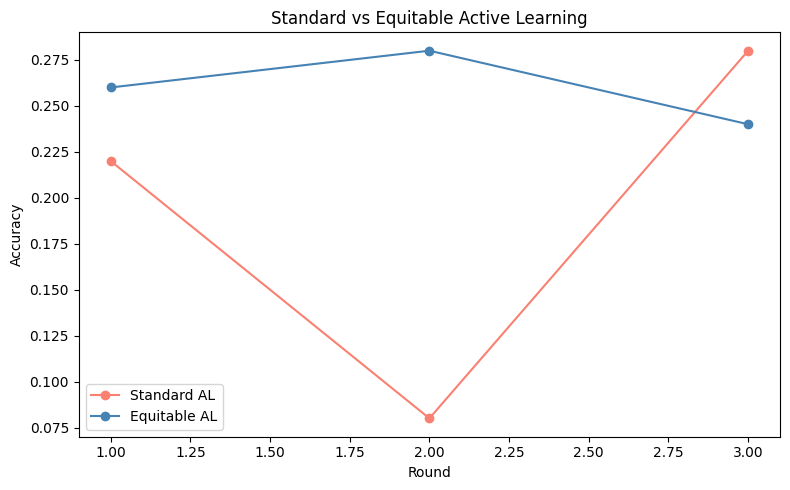


Final Results:
Standard AL final accuracy:  0.28
Equitable AL final accuracy: 0.24

Plot saved


In [9]:
# Plot results
plt.figure(figsize=(8, 5))
plt.plot(range(1, rounds+1), standard_scores, 
         marker='o', color='salmon', label='Standard AL')
plt.plot(range(1, rounds+1), equitable_scores, 
         marker='o', color='steelblue', label='Equitable AL')
plt.title('Standard vs Equitable Active Learning')
plt.xlabel('Round')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/04_active_learning_comparison.png')
plt.show()

print("\nFinal Results:")
print(f"Standard AL final accuracy:  {round(standard_scores[-1], 3)}")
print(f"Equitable AL final accuracy: {round(equitable_scores[-1], 3)}")
print("\nPlot saved")